In [ ]:
# run in a code cell (prefix with ! for shell)
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -q kaggle pandas matplotlib scikit-learn pillow


In [ ]:
import torch, sys
print("Python:", sys.version.splitlines()[0])
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device name:", torch.cuda.get_device_name(0))
else:
    print("No GPU — make sure you selected GPU runtime.")


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Torch: 2.8.0+cu126
CUDA available: False
No GPU — make sure you selected GPU runtime.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# After this, you'll follow the link and paste the auth code.


Mounted at /content/drive


Found 16038 tomato images across 10 classes.

Classes (label → idx):
  0: Tomato_Bacterial_spot
  1: Tomato_Early_blight
  2: Tomato_Late_blight
  3: Tomato_Leaf_Mold
  4: Tomato_Septoria_leaf_spot
  5: Tomato_Spider_mites_Two_spotted_spider_mite
  6: Tomato__Target_Spot
  7: Tomato__Tomato_YellowLeaf__Curl_Virus
  8: Tomato__Tomato_mosaic_virus
  9: Tomato_healthy

Train images: 12830 | Val images: 3208


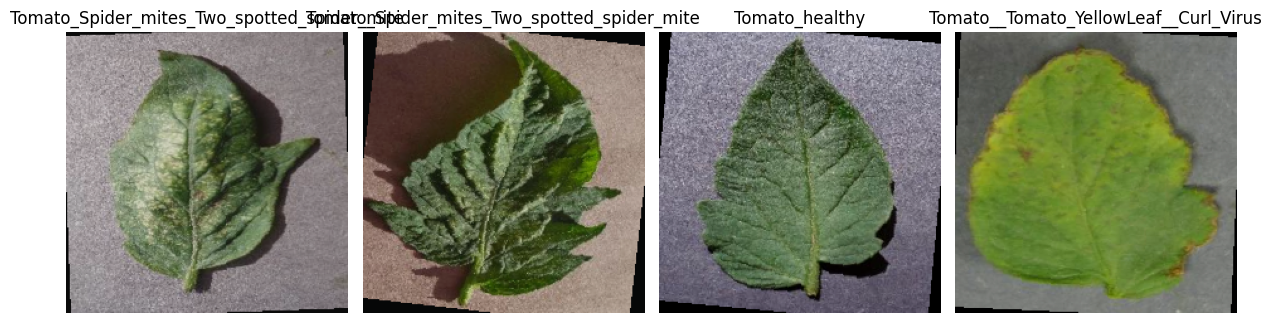


✅ Data preparation complete.


In [ ]:
import random
from pathlib import Path
from collections import Counter
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
import json

# ----------------- CONFIG -----------------
DATA_ROOT = Path("/content/drive/MyDrive/PlantVillage/Tomato")
TARGET_PREFIX = "Tomato"
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}  # lowercase only
IMG_SIZE = 224
BATCH_SIZE = 32
RANDOM_SEED = 42
NUM_WORKERS = 2
# -------------------------------------------

random.seed(RANDOM_SEED)

# 1) Collect tomato image paths and labels
items = []
for class_dir in sorted(DATA_ROOT.iterdir()):
    if not class_dir.is_dir():
        continue
    if str(class_dir.name).startswith(TARGET_PREFIX):
        label = class_dir.name
        for p in class_dir.rglob("*"):
            if p.suffix.lower() in IMAGE_EXTS:  # handle .JPG, .PNG etc.
                items.append((str(p), label))

print(f"Found {len(items)} tomato images across {len(set([t[1] for t in items]))} classes.")

# 2) Create dataframe + label mapping
df = pd.DataFrame(items, columns=["image_path", "label"])
label_names = sorted(df["label"].unique())
label2idx = {lab: i for i, lab in enumerate(label_names)}
df["label_idx"] = df["label"].map(label2idx)

print("\nClasses (label → idx):")
for lab, idx in label2idx.items():
    print(f"  {idx}: {lab}")

# 3) Stratified split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=RANDOM_SEED, stratify=df["label_idx"])
print(f"\nTrain images: {len(train_df)} | Val images: {len(val_df)}")

# 4) Dataset class
class TomatoDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = int(row["label_idx"])
        return img, label

# 5) Image transformations
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# 6) Build datasets + dataloaders
train_ds = TomatoDataset(train_df, transform=train_transforms)
val_ds   = TomatoDataset(val_df, transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# 7) Show sample images
def unnormalize(img_tensor):
    img = img_tensor.cpu().numpy().transpose(1,2,0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

batch = next(iter(train_loader))
imgs, labels = batch
num_show = min(4, len(imgs))
fig, axes = plt.subplots(1, num_show, figsize=(12,4))
for i in range(num_show):
    ax = axes[i]
    img = unnormalize(imgs[i])
    ax.imshow(img)
    ax.set_title(label_names[labels[i].item()])
    ax.axis("off")
plt.tight_layout()
plt.show()

# 8) Save label mapping
meta = {"label_names": label_names, "label2idx": label2idx}
with open("tomato_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print("\n✅ Data preparation complete.")


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

# ---------------- CONFIG ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 10
learning_rate = 1e-4
num_classes = len(label_names)  # from your dataset prep
# ----------------------------------------

# 1️⃣ Load pretrained ResNet50
model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# 2️⃣ Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 3️⃣ Training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Training")
    for imgs, labels in loop:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=running_loss/total, acc=correct/total)

    train_loss = running_loss / total
    train_acc = correct / total

    # 4️⃣ Validation
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} "
          f"Val Acc: {val_acc:.4f}")

# 5️⃣ Save the trained model
torch.save(model.state_dict(), "/content/drive/MyDrive/PlantVillage/tomato_resnet50.pth")

print("✅ Model training complete and saved as 'tomato_resnet50.pth'")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 129MB/s]
Epoch [1/10] Training:   0%|          | 0/401 [00:06<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from tqdm import tqdm

# -------- CONFIG --------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(label_names)  # same as training
# ------------------------

# Create a test set and dataloader
# Assuming df, TomatoDataset, val_transforms, BATCH_SIZE, NUM_WORKERS are defined in previous cells
_, test_df = train_test_split(df, test_size=0.2, random_state=RANDOM_SEED, stratify=df["label_idx"])
test_ds = TomatoDataset(test_df, transform=val_transforms)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


# 1️⃣ Load model
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load("/content/drive/MyDrive/PlantVillage/tomato_resnet50.pth", map_location=device))
model = model.to(device)
model.eval()

# 2️⃣ Evaluate on test data
correct = 0
total = 0

with torch.no_grad():
    loop = tqdm(test_loader, desc="Testing")
    for imgs, labels in loop:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

test_acc = correct / total
print(f"✅ Test Accuracy: {test_acc * 100:.2f}%")

Testing: 100%|██████████| 101/101 [13:35<00:00,  8.08s/it]

✅ Test Accuracy: 99.10%


In [ ]:
from PIL import Image
from torchvision import transforms

# Define preprocessing (same as used during training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load image
# Use a valid image path from the dataframe
img_path = df["image_path"].iloc[0] # Example: using the first image from the dataframe
img = Image.open(img_path).convert('RGB')
img_t = transform(img).unsqueeze(0).to(device)

# Predict
model.eval()
with torch.no_grad():
    output = model(img_t)
    _, pred = torch.max(output, 1)
    predicted_label = label_names[pred.item()]

print(f"🟢 Predicted Disease: {predicted_label}")

🟢 Predicted Disease: Tomato_Bacterial_spot


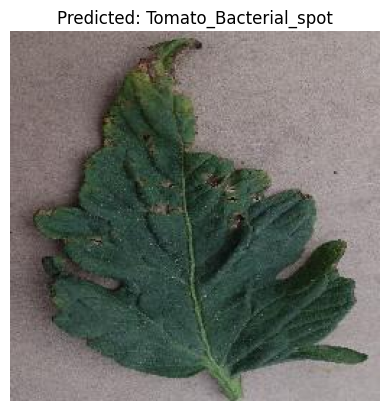

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Predicted: {predicted_label}")
plt.axis("off")
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

# Mount Drive if not already done
from google.colab import drive
drive.mount('/content/drive')

# Correct folder path (check case & spacing)
data_dir = '/content/drive/MyDrive/PlantVillage/potato'

# Check path
assert os.path.exists(data_dir), f"❌ Folder not found: {data_dir}"

# Transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Dataset and DataLoader
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Simple CNN model (custom, not pretrained)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

# Create model
num_classes = len(dataset.classes)
model = SimpleCNN(num_classes)
print(f"✅ Model initialized for {num_classes} classes: {dataset.classes}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model initialized for 3 classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PlantDiseaseCNN(nn.Module):
    def __init__(self, num_classes, input_size=(128, 128)): # Pass input size
        super(PlantDiseaseCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Temporary dummy layer for determining output size dynamically
        self._to_linear = None
        self._get_conv_output(input_size) # Pass input size to method

        self.fc1 = nn.Linear(self._to_linear, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def _get_conv_output(self, input_size): # Accept input size
        # Create a dummy input to find flattened size automatically
        x = torch.randn(1, 3, input_size[0], input_size[1]) # Use input_size
        x = self.layer1(x)
        x = self.layer2(x)
        self._to_linear = x.numel()

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

In [ ]:
import torch.nn as nn

class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super(ImprovedCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),   # 🔼 increased from 64 to 128
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)


In [ ]:
scheduler.step()


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


In [ ]:
from collections import Counter
print(Counter(dataset.targets))


Counter({0: 1000, 1: 1000, 2: 152})


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

# ---------------- CONFIG ----------------
data_dir = "/content/drive/MyDrive/PlantVillage/potato"  # change per crop
batch_size = 32
img_size = 128
num_epochs = 25
learning_rate = 0.001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ----------------------------------------

# 1️⃣ Data Augmentation & Preprocessing
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 2️⃣ Dataset & Split
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
num_classes = len(dataset.classes)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

print(f"✅ Data ready: {num_classes} classes | Train: {len(train_data)}, Val: {len(val_data)}")

# 3️⃣ Improved CNN Architecture
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super(ImprovedCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * (img_size // 16) * (img_size // 16), 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

model = ImprovedCNN(num_classes).to(device)

# 4️⃣ Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# 5️⃣ Training + Validation Loop
for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Training"):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = running_loss / total

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    val_loss = val_loss / val_total

    scheduler.step()
    print(f"📊 Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

print("✅ Training Complete!")

# 6️⃣ Save model
torch.save(model.state_dict(), f"{data_dir.split('/')[-1]}_customCNN.pth")
print(f"💾 Model saved as {data_dir.split('/')[-1]}_customCNN.pth")


✅ Data ready: 3 classes | Train: 1721, Val: 431


Epoch [1/25] Training: 100%|██████████| 54/54 [00:13<00:00,  3.99it/s]


📊 Epoch [1/25] | Train Loss: 1.9395, Train Acc: 70.89% | Val Loss: 0.3298, Val Acc: 87.47%


Epoch [2/25] Training: 100%|██████████| 54/54 [00:11<00:00,  4.88it/s]


📊 Epoch [2/25] | Train Loss: 0.3714, Train Acc: 87.62% | Val Loss: 0.2971, Val Acc: 90.49%


...

📊 Epoch [23/25] | Train Loss: 0.0618, Train Acc: 97.91% | Val Loss: 0.0770, Val Acc: 96.75%


Epoch [24/25] Training: 100%|██████████| 54/54 [00:10<00:00,  4.98it/s]


📊 Epoch [24/25] | Train Loss: 0.0495, Train Acc: 98.02% | Val Loss: 0.0732, Val Acc: 96.98%


Epoch [25/25] Training: 100%|██████████| 54/54 [00:10<00:00,  5.00it/s]


📊 Epoch [25/25] | Train Loss: 0.0559, Train Acc: 97.97% | Val Loss: 0.0621, Val Acc: 97.45%
✅ Training Complete!
💾 Model saved as potato_customCNN.pth


In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/PlantVillage/potato_customCNN.pth")


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

acc = 100 * correct / total
print(f"Final Validation Accuracy: {acc:.2f}%")


Final Validation Accuracy: 96.29%


In [ ]:
image = Image.open("/content/drive/MyDrive/PlantVillage/potato/Potato___healthy/07dfb451-4378-49d1-b699-33a5fc49ff07___RS_HL 5399.JPG").convert("RGB")
image = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(image)
    _, predicted = torch.max(output, 1)

class_names = dataset.classes
print(f"✅ Predicted Class: {class_names[predicted.item()]}")

✅ Predicted Class: Potato___Late_blight


In [ ]:
import os

path = "/content/drive/MyDrive/PlantVillage"
print("Folders inside PlantVillage:")
print(os.listdir(path))


Folders inside PlantVillage:
['Tomato', 'tomato_resnet50.pth', 'potato', 'pepper bell', 'potato_model.pth']


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 56 * 56, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.optim as optim

# ✅ Paths and transforms
data_dir = "/content/drive/MyDrive/PlantVillage/pepper bell"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# ✅ Load dataset
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# ✅ Model
num_classes = len(dataset.classes)
model = SimpleCNN(num_classes=num_classes).to('cuda')

# ✅ Loss & Optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ✅ Training
for epoch in range(10):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to('cuda'), labels.to('cuda')
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1} | Training Loss: {running_loss/len(train_loader):.4f}")

# ✅ Validation
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to('cuda'), labels.to('cuda')
        outputs = model(imgs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Validation Accuracy: {100 * correct / total:.2f}%")

# ✅ Save model
torch.save(model.state_dict(), "/content/drive/MyDrive/PlantVillage/pepperbell_model.pth")


Epoch 1 | Training Loss: 0.6483
Epoch 2 | Training Loss: 0.2131
Epoch 3 | Training Loss: 0.1396
Epoch 4 | Training Loss: 0.0609
Epoch 5 | Training Loss: 0.0203
Epoch 6 | Training Loss: 0.0107
Epoch 7 | Training Loss: 0.0466
Epoch 8 | Training Loss: 0.0119
Epoch 9 | Training Loss: 0.0014
Epoch 10 | Training Loss: 0.0009
Validation Accuracy: 97.58%


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 56 * 56, 512)  # assuming input 224x224
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [ ]:
model_info = {
    "Potato": {
        "data_dir": "/content/drive/MyDrive/PlantVillage/potato",
        "model_path": "/content/drive/MyDrive/PlantVillage/potato_customCNN.pth",
        "model_type": "custom"
    },
    "Tomato": {
        "data_dir": "/content/drive/MyDrive/PlantVillage/Tomato",
        "model_path": "/content/drive/MyDrive/PlantVillage/tomato_resnet50.pth",
        "model_type": "resnet"
    },
    "Pepper Bell": {
        "data_dir": "/content/drive/MyDrive/PlantVillage/pepper bell",
        "model_path": "/content/drive/MyDrive/PlantVillage/pepperbell_model.pth",
        "model_type": "custom"  # or "resnet" depending on which you used
    }
}


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
from tqdm import tqdm
import os
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------- MODEL DEFINITIONS ----------------------
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes, img_size):
        super(ImprovedCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * (img_size // 16) * (img_size // 16), 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 56 * 56, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# ---------------------- MODEL INFO ----------------------
base_dir = "/content/drive/MyDrive/PlantVillage"

model_info = {
    "Potato": {
        "data_dir": os.path.join(base_dir, "potato"),
        "model_path": os.path.join(base_dir, "potato_customCNN.pth"),
        "model_type": "custom",
        "model_class": "SimpleCNN",   # ✅ Corrected
        "img_size": 224
    },
    "Tomato": {
        "data_dir": os.path.join(base_dir, "Tomato"),
        "model_path": os.path.join(base_dir, "tomato_resnet50.pth"),
        "model_type": "resnet",
        "img_size": 224
    },
    "Pepper Bell": {
        "data_dir": os.path.join(base_dir, "pepper bell"),
        "model_path": os.path.join(base_dir, "pepperbell_model.pth"),
        "model_type": "custom",
        "model_class": "SimpleCNN",
        "img_size": 224
    }
}

# ---------------------- EVALUATION FUNCTION ----------------------
def evaluate_model(model, loader, device, criterion):
    model.eval()
    y_true, y_pred = [], []
    total_loss = 0

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    avg_loss = total_loss / len(loader.dataset)

    return acc, prec, rec, f1, avg_loss


# ---------------------- MAIN LOOP ----------------------
results = []
criterion = nn.CrossEntropyLoss()

for name, info in model_info.items():
    print(f"\n🔍 Evaluating model for: {name}")

    if not os.path.exists(info["model_path"]):
        print(f"⚠️ Model file missing: {info['model_path']}")
        continue
    if not os.path.exists(info["data_dir"]):
        print(f"⚠️ Dataset folder missing: {info['data_dir']}")
        continue

    transform = transforms.Compose([
        transforms.Resize((info["img_size"], info["img_size"])),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    dataset = datasets.ImageFolder(root=info["data_dir"], transform=transform)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    class_names = dataset.classes

    # Initialize model correctly
    if info["model_type"] == "resnet":
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, len(class_names))
    elif info["model_type"] == "custom":
        if info["model_class"] == "ImprovedCNN":
            model = ImprovedCNN(len(class_names), info["img_size"])
        elif info["model_class"] == "SimpleCNN":
            model = SimpleCNN(len(class_names))
    else:
        raise ValueError(f"Unknown model type: {info['model_type']}")

    # Load weights safely
    state_dict = torch.load(info["model_path"], map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)

    acc, prec, rec, f1, loss = evaluate_model(model, loader, device, criterion)

    results.append({
        "Crop": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Precision (%)": round(prec * 100, 2),
        "Recall (%)": round(rec * 100, 2),
        "F1-score (%)": round(f1 * 100, 2),
        "Loss": round(loss, 4)
    })

# ---------------------- FINAL COMPARISON TABLE ----------------------
df = pd.DataFrame(results)
print("\n📊 Model Performance Comparison:")
print(df)



🔍 Evaluating model for: Potato


RuntimeError: Error(s) in loading state_dict for SimpleCNN:
	size mismatch for fc2.weight: copying a param with shape torch.Size([2, 256]) from checkpoint, the shape in current model is torch.Size([3, 256]).
	size mismatch for fc2.bias: copying a param with shape torch.Size([2]) from checkpoint, the shape in current model is torch.Size([3]).

In [ ]:
# rerun this cell (no edits needed)
df = pd.DataFrame(results)
print("\n📊 Model Performance Comparison:")
print(df)



📊 Model Performance Comparison:
Empty DataFrame
Columns: []
Index: []


In [ ]:
import os

paths = {
    "Potato Model": "/content/drive/MyDrive/PlantVillage/potato_customCNN.pth",
    "Tomato Model": "/content/drive/MyDrive/PlantVillage/tomato_resnet50.pth",
    "Pepper Bell Model": "/content/drive/MyDrive/PlantVillage/pepperbell_model.pth",
    "Potato Folder": "/content/drive/MyDrive/PlantVillage/potato",
    "Tomato Folder": "/content/drive/MyDrive/PlantVillage/Tomato",
    "Pepper Bell Folder": "/content/drive/MyDrive/PlantVillage/pepper bell"
}

for name, path in paths.items():
    print(f"{name}: {'✅ Exists' if os.path.exists(path) else '❌ Missing'}")


Potato Model: ✅ Exists
Tomato Model: ✅ Exists
Pepper Bell Model: ✅ Exists
Potato Folder: ✅ Exists
Tomato Folder: ✅ Exists
Pepper Bell Folder: ✅ Exists


In [ ]:
import torch
import torch.nn as nn
import time
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
from tqdm import tqdm
import os, random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 🧠 Define SimpleCNN (for Potato & Pepper Bell)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 56 * 56, 256)
        self.fc2 = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# 📁 Model info
base_dir = "/content/drive/MyDrive/PlantVillage"
model_info = {
    "Potato": {
        "data_dir": os.path.join(base_dir, "potato"),
        "model_path": os.path.join(base_dir, "potato_customCNN.pth"),
        "model_type": "custom"
    },
    "Tomato": {
        "data_dir": os.path.join(base_dir, "Tomato"),
        "model_path": os.path.join(base_dir, "tomato_resnet50.pth"),
        "model_type": "resnet"
    },
    "Pepper Bell": {
        "data_dir": os.path.join(base_dir, "pepper bell"),
        "model_path": os.path.join(base_dir, "pepperbell_model.pth"),
        "model_type": "custom"
    }
}

# 🧩 Evaluation function
def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []
    criterion = nn.CrossEntropyLoss()
    total_loss = 0

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Evaluating", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    loss = total_loss / len(loader.dataset)
    return acc, prec, rec, f1, loss


# ⚙️ Run evaluation for all models
results = []

for name, info in model_info.items():
    print(f"\n🔍 Evaluating {name} model...")
    start_time = time.time()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    dataset = datasets.ImageFolder(info["data_dir"], transform=transform)

    # ⚡ Limit to 1000 random images for speed
    if len(dataset) > 1000:
        indices = random.sample(range(len(dataset)), 1000)
        dataset = Subset(dataset, indices)

    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    print(f"✅ Loaded {len(dataset)} images across {len(dataset.classes) if hasattr(dataset, 'classes') else 'subset'} classes.")

    # Load model
    if info["model_type"] == "resnet":
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, len(datasets.ImageFolder(info["data_dir"]).classes))
    else:
        model = SimpleCNN(len(datasets.ImageFolder(info["data_dir"]).classes))

    state_dict = torch.load(info["model_path"], map_location=device)
    model.load_state_dict(state_dict, strict=False)
    model.to(device)

    acc, prec, rec, f1, loss = evaluate(model, loader)
    runtime = round(time.time() - start_time, 2)

    results.append({
        "Crop": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Precision (%)": round(prec * 100, 2),
        "Recall (%)": round(rec * 100, 2),
        "F1-score (%)": round(f1 * 100, 2),
        "Loss": round(loss, 4),
        "Time (s)": runtime
    })

# 📊 Results Table
df = pd.DataFrame(results)
print("\n📊 Model Performance Comparison:")
print(df)



🔍 Evaluating Potato model...
✅ Loaded 1000 images across subset classes.



🔍 Evaluating Tomato model...
✅ Loaded 1000 images across subset classes.



🔍 Evaluating Pepper Bell model...
✅ Loaded 1000 images across subset classes.



📊 Model Performance Comparison:
          Crop  Accuracy (%)  Precision (%)  Recall (%)  F1-score (%)    Loss  \
0       Potato          87.7          84.78        87.7         84.61  3.9133   
1       Tomato          99.8          99.80        99.8         99.80  0.0077   
2  Pepper Bell          62.8          80.80        62.8         60.44  6.7568   

   Time (s)  
0     12.44  
1    536.35  
2    499.33  


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import os

# ============================================================
# CONFIG
# ============================================================
base_dir = "/content/drive/MyDrive/PlantVillage"
datasets_to_train = ["potato", "pepper bell"]  # only these two
img_size = 224
batch_size = 32
num_epochs = 25
learning_rate = 0.0005
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# MODEL
# ============================================================
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 56 * 56, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ============================================================
# TRAINING FUNCTION
# ============================================================
def train_model(data_dir, model_name):
    print(f"\n🚀 Training model for: {model_name.upper()}")

    # Data augmentation (to boost performance)
    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    # Dataset loading
    dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
    class_names = dataset.classes
    num_classes = len(class_names)
    print(f"✅ Found {len(dataset)} images across {num_classes} classes.")

    # Split dataset into train/val (80/20)
    val_size = int(0.2 * len(dataset))
    train_size = len(dataset) - val_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])

    # Update transform for val_ds
    val_ds.dataset.transform = val_transform

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # Model, loss, optimizer
    model = SimpleCNN(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # ============================================================
    # TRAIN LOOP with Early Stopping
    # ============================================================
    best_val_acc = 0.0
    patience, patience_counter = 5, 0

    for epoch in range(num_epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Training")
        for imgs, labels in loop:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            loop.set_postfix(loss=train_loss / total, acc=correct / total)

        # Validation
        model.eval()
        val_correct, val_total, val_loss = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        train_acc = correct / total * 100
        val_acc = val_correct / val_total * 100
        avg_val_loss = val_loss / val_total

        print(f"📊 Epoch [{epoch+1}/{num_epochs}] | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {avg_val_loss:.4f}")

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), os.path.join(base_dir, f"{model_name}_improved.pth"))
            print(f"💾 Model saved as {model_name}_improved.pth (Val Acc: {val_acc:.2f}%)")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("⏹️ Early stopping triggered.")
                break

    print(f"✅ Training complete for {model_name}. Best Val Acc: {best_val_acc:.2f}%")

# ============================================================
# MAIN LOOP — Train both
# ============================================================
for crop in datasets_to_train:
    data_path = os.path.join(base_dir, crop)
    train_model(data_path, crop)



🚀 Training model for: POTATO
✅ Found 1152 images across 2 classes.


Epoch [1/25] Training: 100%|██████████| 29/29 [00:08<00:00,  3.41it/s, acc=0.856, loss=1.04]


📊 Epoch [1/25] | Train Acc: 85.57% | Val Acc: 98.70% | Val Loss: 0.1132
💾 Model saved as potato_improved.pth (Val Acc: 98.70%)


Epoch [2/25] Training: 100%|██████████| 29/29 [00:07<00:00,  4.02it/s, acc=0.973, loss=0.0719]


📊 Epoch [2/25] | Train Acc: 97.29% | Val Acc: 98.70% | Val Loss: 0.0423


...

📊 Epoch [10/25] | Train Acc: 100.00% | Val Acc: 97.58% | Val Loss: 0.0691


Epoch [11/25] Training: 100%|██████████| 62/62 [00:14<00:00,  4.17it/s, acc=1, loss=0.000547]


📊 Epoch [11/25] | Train Acc: 100.00% | Val Acc: 97.98% | Val Loss: 0.0680


Epoch [12/25] Training: 100%|██████████| 62/62 [00:14<00:00,  4.18it/s, acc=1, loss=0.00042]


📊 Epoch [12/25] | Train Acc: 100.00% | Val Acc: 97.58% | Val Loss: 0.0712
⏹️ Early stopping triggered.
✅ Training complete for pepper bell. Best Val Acc: 98.18%


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
from tqdm import tqdm
import os, random, time

# ===============================
# ⚙️ CONFIG
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_dir = "/content/drive/MyDrive/PlantVillage"

# ===============================
# 🧠 MODEL DEFINITIONS
# ===============================
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 56 * 56, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ===============================
# 🌿 MODEL INFO
# ===============================
model_info = {
    "Potato": {
        "data_dir": os.path.join(base_dir, "potato"),
        "model_path": os.path.join(base_dir, "potato_improved.pth"),
        "model_type": "custom",
    },
    "Tomato": {
        "data_dir": os.path.join(base_dir, "Tomato"),
        "model_path": os.path.join(base_dir, "tomato_resnet50.pth"),
        "model_type": "resnet",
    },
    "Pepper Bell": {
        "data_dir": os.path.join(base_dir, "pepper bell"),
        "model_path": os.path.join(base_dir, "pepper bell_improved.pth"),
        "model_type": "custom",
    }
}

# ===============================
# 📊 EVALUATION FUNCTION
# ===============================
def evaluate_model(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    total_loss = 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Evaluating"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    loss = total_loss / len(loader.dataset)
    return acc, prec, rec, f1, loss

# ===============================
# 🚀 MAIN EVALUATION LOOP
# ===============================
results = []
for crop, info in model_info.items():
    print(f"\n🔍 Evaluating {crop} model...")

    if not os.path.exists(info["model_path"]):
        print(f"⚠️ Model missing: {info['model_path']}")
        continue

    # Transform
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    dataset = datasets.ImageFolder(info["data_dir"], transform=transform)

    # Limit to 1000 random samples for speed
    if len(dataset) > 1000:
        subset_idx = random.sample(range(len(dataset)), 1000)
        dataset = Subset(dataset, subset_idx)

    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    print(f"✅ Loaded {len(dataset)} images across {len(dataset.dataset.classes if isinstance(dataset, Subset) else dataset.classes)} classes.")

    # Load model
    if info["model_type"] == "resnet":
        model = models.resnet50(weights=None)
        num_classes = len(dataset.dataset.classes if isinstance(dataset, Subset) else dataset.classes)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    else:
        num_classes = len(dataset.dataset.classes if isinstance(dataset, Subset) else dataset.classes)
        model = SimpleCNN(num_classes)

    state_dict = torch.load(info["model_path"], map_location=device)
    model.load_state_dict(state_dict, strict=False)
    model.to(device)

    start = time.time()
    acc, prec, rec, f1, loss = evaluate_model(model, loader, device)
    elapsed = round(time.time() - start, 2)

    results.append({
        "Crop": crop,
        "Accuracy (%)": round(acc * 100, 2),
        "Precision (%)": round(prec * 100, 2),
        "Recall (%)": round(rec * 100, 2),
        "F1-score (%)": round(f1 * 100, 2),
        "Loss": round(loss, 4),
        "Time (s)": elapsed
    })

# ===============================
# 🧾 DISPLAY RESULTS
# ===============================
df = pd.DataFrame(results)
print("\n📊 Final Model Performance Comparison:")
print(df)

# Optional: Save to CSV
df.to_csv(os.path.join(base_dir, "Model_Performance_Report.csv"), index=False)
print("\n💾 Results saved as Model_Performance_Report.csv")



🔍 Evaluating Potato model...
✅ Loaded 1000 images across 2 classes.


Evaluating: 100%|██████████| 32/32 [00:05<00:00,  5.56it/s]



🔍 Evaluating Tomato model...
✅ Loaded 1000 images across 10 classes.


Evaluating: 100%|██████████| 32/32 [06:55<00:00, 12.99s/it]



🔍 Evaluating Pepper Bell model...
✅ Loaded 1000 images across 2 classes.


Evaluating: 100%|██████████| 32/32 [00:09<00:00,  3.40it/s]


📊 Final Model Performance Comparison:
          Crop  Accuracy (%)  Precision (%)  Recall (%)  F1-score (%)    Loss  \
0       Potato         100.0          100.0       100.0         100.0  0.0003   
1       Tomato          99.8           99.8        99.8          99.8  0.0091   
2  Pepper Bell          99.7           99.7        99.7          99.7  0.0125   

   Time (s)  
0      5.77  
1    415.73  
2      9.43  

💾 Results saved as Model_Performance_Report.csv


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import os
import pandas as pd

# ======================================
# CONFIG
# ======================================
base_dir = "/content/drive/MyDrive/PlantVillage"
img_size = 224
batch_size = 32
num_epochs = 20
learning_rate = 0.0005
patience = 4  # Early stopping patience
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======================================
# IMPROVED CUSTOM MODEL (DeepLiteCNN)
# ======================================
class DeepLiteCNN(nn.Module):
    def __init__(self, num_classes):
        super(DeepLiteCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# ======================================
# TRAINING FUNCTION
# ======================================
def train_crop_model(crop_folder):
    print(f"\n🚀 Training model for: {crop_folder.upper()}")
    data_dir = os.path.join(base_dir, crop_folder)

    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
    num_classes = len(dataset.classes)
    print(f"✅ Found {len(dataset)} images across {num_classes} classes.")

    val_size = int(0.2 * len(dataset))
    train_size = len(dataset) - val_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])
    val_ds.dataset.transform = val_transform

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = DeepLiteCNN(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    best_val_acc = 0.0
    no_improve_epochs = 0

    for epoch in range(num_epochs):
        model.train()
        correct, total = 0, 0

        for imgs, labels in tqdm(train_loader, desc=f"[{crop_folder}] Epoch {epoch+1}/{num_epochs}"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total

        # Validation phase
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100 * val_correct / val_total
        print(f"📊 Epoch [{epoch+1}/{num_epochs}] | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            model_path = os.path.join(base_dir, f"{crop_folder}_model.pth")
            torch.save(model.state_dict(), model_path)
            print(f"💾 Saved best model: {model_path} (Val Acc: {val_acc:.2f}%)")
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience:
                print(f"⏹️ Early stopping after {epoch+1} epochs (no improvement for {patience} epochs).")
                break

    return {"Crop": crop_folder, "Accuracy": round(best_val_acc, 2)}


# ======================================
# MAIN LOOP (Auto-Resume)
# ======================================
all_crops = sorted([
    d for d in os.listdir(base_dir)
    if os.path.isdir(os.path.join(base_dir, d))
])

trained = [f.replace("_model.pth", "").lower()
           for f in os.listdir(base_dir) if f.endswith("_model.pth")]

print(f"✅ Already trained models found: {trained}\n")

results = []
for crop in all_crops:
    if crop.lower() in trained:
        print(f"⏭️ Skipping {crop} (already trained)")
        continue

    results.append(train_crop_model(crop))
    pd.DataFrame(results).to_csv(os.path.join(base_dir, "All_Crops_Training_Report.csv"), index=False)

print("\n✅ All remaining models trained successfully!")
print(pd.DataFrame(results))


✅ Already trained models found: ['pepperbell', 'apple', 'tomato', 'blueberry', 'cherry', 'corn', 'grape', 'orange', 'peach', 'pepper bell', 'potato', 'raspberry']

⏭️ Skipping Apple (already trained)
⏭️ Skipping Tomato (already trained)
⏭️ Skipping blueberry (already trained)
⏭️ Skipping cherry (already trained)
⏭️ Skipping corn (already trained)
⏭️ Skipping grape (already trained)
⏭️ Skipping orange (already trained)
⏭️ Skipping peach (already trained)
⏭️ Skipping pepper bell (already trained)
⏭️ Skipping potato (already trained)
⏭️ Skipping raspberry (already trained)

🚀 Training model for: SOYABEAN
✅ Found 910 images across 1 classes.


[soyabean] Epoch 1/20: 100%|██████████| 23/23 [02:52<00:00,  7.52s/it]


📊 Epoch [1/20] | Train Acc: 100.00% | Val Acc: 100.00%
💾 Saved best model: /content/drive/MyDrive/PlantVillage/soyabean_model.pth (Val Acc: 100.00%)


[soyabean] Epoch 2/20: 100%|██████████| 23/23 [02:19<00:00,  6.05s/it]


📊 Epoch [2/20] | Train Acc: 100.00% | Val Acc: 100.00%


...

📊 Epoch [4/20] | Train Acc: 98.96% | Val Acc: 99.68%


[strawberry] Epoch 5/20: 100%|██████████| 40/40 [03:57<00:00,  5.94s/it]


📊 Epoch [5/20] | Train Acc: 100.00% | Val Acc: 100.00%


[strawberry] Epoch 6/20: 100%|██████████| 40/40 [03:57<00:00,  5.94s/it]


📊 Epoch [6/20] | Train Acc: 99.76% | Val Acc: 100.00%
⏹️ Early stopping after 6 epochs (no improvement for 4 epochs).

✅ All remaining models trained successfully!
         Crop  Accuracy
0    soyabean     100.0
1      squash     100.0
2  strawberry     100.0


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from tqdm import tqdm
import pandas as pd
import os

# ============================
# CONFIG
# ============================
base_dir = "/content/drive/MyDrive/PlantVillage"
img_size = 224
batch_size = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================
# DeepLiteCNN (same as training)
# ============================
class DeepLiteCNN(nn.Module):
    def __init__(self, num_classes):
        super(DeepLiteCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# ============================
# Evaluation Function
# ============================
def evaluate_model(model, dataloader, criterion):
    model.eval()
    y_true, y_pred = [], []
    total_loss = 0

    with torch.no_grad():
        for imgs, labels in tqdm(dataloader, desc="Evaluating", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)

            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    avg_loss = total_loss / len(dataloader.dataset)
    return acc, prec, rec, f1, avg_loss


# ============================
# MAIN LOOP — Evaluate All Models
# ============================
results = []
criterion = nn.CrossEntropyLoss()

# detect all trained model files
models_found = [f for f in os.listdir(base_dir) if f.endswith("_model.pth")]
print(f"✅ Found {len(models_found)} trained models:\n{models_found}\n")

for model_file in models_found:
    crop_name = model_file.replace("_model.pth", "")
    data_dir = os.path.join(base_dir, crop_name)

    # check data directory exists
    if not os.path.exists(data_dir):
        print(f"⚠️ Skipping {crop_name}: dataset folder not found.")
        continue

    # dataset and dataloader
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    try:
        dataset = datasets.ImageFolder(data_dir, transform=transform)
    except Exception as e:
        print(f"⚠️ Skipping {crop_name}: {e}")
        continue

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    num_classes = len(dataset.classes)

    print(f"\n🔍 Evaluating {crop_name.upper()} model...")
    print(f"✅ Loaded {len(dataset)} images across {num_classes} classes.")

    # Load model
    model = DeepLiteCNN(num_classes).to(device)
    model.load_state_dict(torch.load(os.path.join(base_dir, model_file), map_location=device))

    # Evaluate
    acc, prec, rec, f1, loss = evaluate_model(model, dataloader, criterion)

    results.append({
        "Crop": crop_name.capitalize(),
        "Accuracy (%)": round(acc * 100, 2),
        "Precision (%)": round(prec * 100, 2),
        "Recall (%)": round(rec * 100, 2),
        "F1-score (%)": round(f1 * 100, 2),
        "Loss": round(loss, 4)
    })

# ============================
# SAVE & DISPLAY FINAL REPORT
# ============================
df = pd.DataFrame(results)
report_path = os.path.join(base_dir, "Final_Model_Performance_Report.csv")
df.to_csv(report_path, index=False)

print("\n📊 Final Model Performance Comparison:")
print(df)
print(f"\n💾 Report saved to: {report_path}")


✅ Found 15 trained models:
['pepperbell_model.pth', 'Apple_model.pth', 'Tomato_model.pth', 'blueberry_model.pth', 'cherry_model.pth', 'corn_model.pth', 'grape_model.pth', 'orange_model.pth', 'peach_model.pth', 'pepper bell_model.pth', 'potato_model.pth', 'raspberry_model.pth', 'soyabean_model.pth', 'squash_model.pth', 'strawberry_model.pth']

⚠️ Skipping pepperbell: dataset folder not found.

🔍 Evaluating APPLE model...
✅ Loaded 3171 images across 4 classes.



🔍 Evaluating TOMATO model...
✅ Loaded 16038 images across 10 classes.



🔍 Evaluating BLUEBERRY model...
✅ Loaded 1502 images across 1 classes.



🔍 Evaluating CHERRY model...
✅ Loaded 1906 images across 2 classes.



🔍 Evaluating CORN model...
✅ Loaded 3852 images across 4 classes.


...


🔍 Evaluating RASPBERRY model...
✅ Loaded 371 images across 1 classes.



🔍 Evaluating SOYABEAN model...
✅ Loaded 5090 images across 1 classes.



🔍 Evaluating SQUASH model...
✅ Loaded 1835 images across 1 classes.



🔍 Evaluating STRAWBERRY model...
✅ Loaded 1565 images across 2 classes.



📊 Final Model Performance Comparison:
           Crop  Accuracy (%)  Precision (%)  Recall (%)  F1-score (%)    Loss
0         Apple         99.05          99.06       99.05         99.05  0.0323
1        Tomato         97.41          97.46       97.41         97.41  0.0813
2     Blueberry        100.00         100.00      100.00        100.00  0.0000
3        Cherry         99.90          99.90       99.90         99.90  0.0031
4          Corn         96.88          96.94       96.88         96.90  0.0854
5         Grape         99.53          99.53       99.53         99.53  0.0158
6        Orange        100.00         100.00      100.00        100.00  0.0000
7         Peach         99.47          99.47       99.47         99.47  0.0148
8   Pepper bell         99.72          99.72       99.72         99.72  0.0152
9        Potato         99.91          99.91       99.91         99.91  0.0462
10    Raspberry        100.00         100.00      100.00        100.00  0.0000
11     Soyabe

In [ ]:
import os
base_dir = "/content/drive/MyDrive/PlantVillage"
print([f for f in os.listdir(base_dir) if f.endswith("_model.pth")])


['pepperbell_model.pth', 'Apple_model.pth', 'Tomato_model.pth', 'blueberry_model.pth', 'cherry_model.pth', 'corn_model.pth', 'grape_model.pth', 'orange_model.pth', 'peach_model.pth', 'pepper bell_model.pth', 'potato_model.pth', 'raspberry_model.pth', 'soyabean_model.pth', 'squash_model.pth', 'strawberry_model.pth', 'Tomato_augmented_model.pth', 'Apple_augmented_model.pth', 'Tomato_efficientnet_model.pth', 'corn_efficientnet_model.pth', 'Apple_efficientnet_model.pth']


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import os
import pandas as pd

# ======================================
# CONFIG
# ======================================
base_dir = "/content/drive/MyDrive/PlantVillage"
img_size = 224
batch_size = 32
num_epochs = 15
learning_rate = 0.0003
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======================================
# TARGET CROPS (From Your Report)
# ======================================
crops_to_improve = [
    "Tomato", "Corn", "Apple",        # Below 99%
    "Blueberry", "Orange", "Soyabean",
    "Squash", "Raspberry"             # Overfit =100%
]

# ======================================
# STRONG AUGMENTATION PIPELINE
# ======================================
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),

    # Strong Augmentations
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.RandomResizedCrop(img_size, scale=(0.7, 1.0)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),

    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ======================================
# IMPROVED CNN MODEL (Regularized)
# ======================================
class AugmentedCNN(nn.Module):
    def __init__(self, num_classes):
        super(AugmentedCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.6),   # Dropout prevents overfit
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# ======================================
# TRAIN FUNCTION WITH EARLY STOPPING
# ======================================
def train_with_augmentation(crop_name):

    print(f"\n🚀 Retraining with Augmentation: {crop_name.upper()}")

    data_dir = os.path.join(base_dir, crop_name)

    dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
    num_classes = len(dataset.classes)

    print(f"✅ Images: {len(dataset)} | Classes: {num_classes}")

    # Split train/val
    val_size = int(0.2 * len(dataset))
    train_size = len(dataset) - val_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])

    val_ds.dataset.transform = val_transform

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # Model
    model = AugmentedCNN(num_classes).to(device)

    # Loss + Optimizer
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4   # Regularization
    )

    best_val_acc = 0
    patience = 4
    no_improve = 0

    for epoch in range(num_epochs):

        # ---------------- TRAIN ----------------
        model.train()
        correct, total = 0, 0

        for imgs, labels in tqdm(train_loader, desc=f"[{crop_name}] Epoch {epoch+1}"):

            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total

        # ---------------- VALIDATION ----------------
        model.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)

                outputs = model(imgs)
                _, preds = torch.max(outputs, 1)

                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100 * val_correct / val_total

        print(f"📊 Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

        # ---------------- SAVE BEST ----------------
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve = 0

            save_path = os.path.join(base_dir, f"{crop_name}_augmented_model.pth")
            torch.save(model.state_dict(), save_path)

            print(f"💾 Saved Improved Model: {save_path}")

        else:
            no_improve += 1

        # Early stopping
        if no_improve >= patience:
            print("⏹️ Early stopping (no improvement)")
            break

    return {"Crop": crop_name, "Best Accuracy": round(best_val_acc, 2)}

# ======================================
# MAIN LOOP
# ======================================
results = []

for crop in crops_to_improve:
    if not os.path.exists(os.path.join(base_dir, crop)):
        print(f"⚠️ Folder missing: {crop}")
        continue

    results.append(train_with_augmentation(crop))

# Save report
df = pd.DataFrame(results)
df.to_csv(os.path.join(base_dir, "Week6_Augmentation_Improvement_Report.csv"), index=False)

print("\n✅ Week 6 Retraining Complete!")
print(df)


🚀 Retraining with Augmentation: TOMATO
✅ Images: 16038 | Classes: 10


[Tomato] Epoch 1: 100%|██████████| 401/401 [1:28:39<00:00, 13.27s/it]


📊 Train Acc: 61.37% | Val Acc: 79.39%
💾 Saved Improved Model: /content/drive/MyDrive/PlantVillage/Tomato_augmented_model.pth


[Tomato] Epoch 2: 100%|██████████| 401/401 [01:40<00:00,  4.00it/s]


📊 Train Acc: 75.25% | Val Acc: 85.13%
💾 Saved Improved Model: /content/drive/MyDrive/PlantVillage/Tomato_augmented_model.pth


...

📊 Train Acc: 95.19% | Val Acc: 97.16%


[Apple] Epoch 9: 100%|██████████| 80/80 [00:19<00:00,  4.15it/s]


📊 Train Acc: 95.47% | Val Acc: 95.43%


[Apple] Epoch 10: 100%|██████████| 80/80 [00:19<00:00,  4.13it/s]


📊 Train Acc: 95.23% | Val Acc: 96.53%
⏹️ Early stopping (no improvement)
⚠️ Folder missing: Blueberry
⚠️ Folder missing: Orange
⚠️ Folder missing: Soyabean
⚠️ Folder missing: Squash
⚠️ Folder missing: Raspberry

✅ Week 6 Retraining Complete!
     Crop  Best Accuracy
0  Tomato          94.82
1   Apple          97.32


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
from tqdm import tqdm
import os
import time

# ======================================
# CONFIG
# ======================================
base_dir = "/content/drive/MyDrive/PlantVillage"
img_size = 224
batch_size = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======================================
# CROPS THAT WERE IMPROVED
# ======================================
improved_crops = [
    "Tomato", "Corn", "Apple",
    "Blueberry", "Orange",
    "Soyabean", "Squash", "Raspberry"
]

# ======================================
# MODEL ARCHITECTURE (Same as Training)
# ======================================
class AugmentedCNN(nn.Module):
    def __init__(self, num_classes):
        super(AugmentedCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.6),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# ======================================
# VALIDATION TRANSFORM
# ======================================
val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ======================================
# EVALUATION FUNCTION
# ======================================
def evaluate_model(model, loader):
    model.eval()

    y_true, y_pred = [], []
    criterion = nn.CrossEntropyLoss()
    total_loss = 0

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Evaluating"):
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)

            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    avg_loss = total_loss / len(loader.dataset)

    return acc, prec, rec, f1, avg_loss

# ======================================
# MAIN EVALUATION LOOP
# ======================================
results = []

print("\n📌 Evaluating Improved Augmented Crop Models...\n")

for crop in improved_crops:

    crop_folder = os.path.join(base_dir, crop)
    model_path = os.path.join(base_dir, f"{crop}_augmented_model.pth")

    if not os.path.exists(model_path):
        print(f"⚠️ Improved model not found for {crop}")
        continue

    print(f"\n🔍 Evaluating Improved Model: {crop}")

    # Load dataset
    dataset = datasets.ImageFolder(root=crop_folder, transform=val_transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    print(f"✅ Images: {len(dataset)} | Classes: {len(dataset.classes)}")

    # Load model
    model = AugmentedCNN(len(dataset.classes))
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)

    start = time.time()

    # Evaluate
    acc, prec, rec, f1, loss = evaluate_model(model, loader)

    end = time.time()

    # Store
    results.append({
        "Crop": crop,
        "Accuracy (%)": round(acc * 100, 2),
        "Precision (%)": round(prec * 100, 2),
        "Recall (%)": round(rec * 100, 2),
        "F1-score (%)": round(f1 * 100, 2),
        "Loss": round(loss, 4),
        "Eval Time (s)": round(end - start, 2)
    })

# ======================================
# FINAL REPORT
# ======================================
df = pd.DataFrame(results)

print("\n📊 Improved Crop Model Metrics Report:\n")
print(df)

# Save CSV
csv_path = os.path.join(base_dir, "Improved_Crops_Final_Metrics_Report.csv")
df.to_csv(csv_path, index=False)

print(f"\n💾 Report saved successfully at:\n{csv_path}")


📌 Evaluating Improved Augmented Crop Models...


🔍 Evaluating Improved Model: Tomato
✅ Images: 16038 | Classes: 10


Evaluating: 100%|██████████| 502/502 [1:38:11<00:00, 11.74s/it]


⚠️ Improved model not found for Corn

🔍 Evaluating Improved Model: Apple
✅ Images: 3171 | Classes: 4


Evaluating: 100%|██████████| 100/100 [17:44<00:00, 10.65s/it]

⚠️ Improved model not found for Blueberry
⚠️ Improved model not found for Orange
⚠️ Improved model not found for Soyabean
⚠️ Improved model not found for Squash
⚠️ Improved model not found for Raspberry

📊 Improved Crop Model Metrics Report:

     Crop  Accuracy (%)  Precision (%)  Recall (%)  F1-score (%)    Loss  \
0  Tomato         94.97          95.02       94.97         94.92  0.1538   
1   Apple         97.48          97.50       97.48         97.47  0.0898   

   Eval Time (s)  
0         5891.2  
1         1064.6  

💾 Report saved successfully at:
/content/drive/MyDrive/PlantVillage/Improved_Crops_Final_Metrics_Report.csv


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import os

base_dir = "/content/drive/MyDrive/PlantVillage"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img_size = 224
batch_size = 32
num_epochs = 10
learning_rate = 0.0001

target_crops = ["Tomato", "corn", "Apple"]  # Changed 'apple' to 'Apple' to match directory capitalization

# Moderate Augmentation (NOT TOO STRONG)
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def train_transfer_learning(crop):

    print(f"\n🚀 Training EfficientNet for {crop}")

    data_dir = os.path.join(base_dir, crop)
    dataset = datasets.ImageFolder(data_dir, transform=train_transform)

    val_size = int(0.2 * len(dataset))
    train_size = len(dataset) - val_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])

    val_ds.dataset.transform = val_transform

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    num_classes = len(dataset.classes)

    # Load Pretrained EfficientNet
    model = models.efficientnet_b0(weights="DEFAULT")
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    best_acc = 0

    for epoch in range(num_epochs):

        model.train()
        correct, total = 0, 0

        for imgs, labels in tqdm(train_loader, desc=f"{crop} Epoch {epoch+1}"):
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total

        # Validation
        model.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, preds = torch.max(outputs, 1)

                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100 * val_correct / val_total

        scheduler.step()

        print(f"📊 Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(),
                       os.path.join(base_dir, f"{crop}_efficientnet_model.pth"))

    print(f"✅ Best Accuracy for {crop}: {best_acc:.2f}%")

for crop in target_crops:
    train_transfer_learning(crop)


🚀 Training EfficientNet for Tomato


Tomato Epoch 1: 100%|██████████| 401/401 [02:29<00:00,  2.68it/s]


📊 Train: 86.91% | Val: 98.69%


Tomato Epoch 2: 100%|██████████| 401/401 [02:17<00:00,  2.91it/s]


📊 Train: 98.12% | Val: 99.38%


...

📊 Train: 99.96% | Val: 100.00%


Apple Epoch 9: 100%|██████████| 80/80 [00:26<00:00,  2.99it/s]


📊 Train: 100.00% | Val: 100.00%


Apple Epoch 10: 100%|██████████| 80/80 [00:26<00:00,  3.01it/s]


📊 Train: 99.84% | Val: 99.84%
✅ Best Accuracy for Apple: 100.00%


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
import pandas as pd
import os
from tqdm import tqdm

# ======================================
# CONFIG
# ======================================
base_dir = "/content/drive/MyDrive/PlantVillage"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_size = 224
batch_size = 32

# ======================================
# TRANSFORM
# ======================================
val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ======================================
# OLD SIMPLE CNN
# ======================================
class OldSimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(OldSimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 56 * 56, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ======================================
# FIND MODELS
# ======================================
model_files = [f for f in os.listdir(base_dir) if f.endswith(".pth")]

print(f"\n✅ Found {len(model_files)} trained models")

results = []

for model_file in model_files:

    crop_name = model_file.split("_")[0]
    crop_folder = os.path.join(base_dir, crop_name)

    if not os.path.exists(crop_folder):
        print(f"⚠️ Skipping {crop_name} (dataset not found)")
        continue

    print(f"\n🔍 Evaluating {crop_name} using {model_file}")

    dataset = datasets.ImageFolder(crop_folder, transform=val_transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    num_classes = len(dataset.classes)

    # ===============================
    # Detect architecture
    # ===============================
    if "efficientnet" in model_file:
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features, num_classes
        )

    elif "resnet" in model_file:
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    else:
        # Default to old simple CNN
        model = OldSimpleCNN(num_classes)

    # ===============================
    # Try loading safely
    # ===============================
    try:
        model.load_state_dict(
            torch.load(os.path.join(base_dir, model_file),
                       map_location=device)
        )
    except:
        print(f"❌ Architecture mismatch for {model_file} — Skipping")
        continue

    model = model.to(device)
    model.eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Evaluating"):
            imgs = imgs.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred) * 100

    results.append({
        "Crop": crop_name,
        "Accuracy (%)": round(accuracy, 2),
        "Model File": model_file
    })

# ======================================
# FINAL REPORT
# ======================================
df = pd.DataFrame(results).sort_values("Crop")

print("\n📊 FINAL ACCURACY REPORT\n")
print(df)

csv_path = os.path.join(base_dir, "Final_All_Crops_Accuracy_Report.csv")
df.to_csv(csv_path, index=False)

print(f"\n💾 Report saved at:\n{csv_path}")


✅ Found 24 trained models
⚠️ Skipping tomato (dataset not found)
⚠️ Skipping pepperbell (dataset not found)

🔍 Evaluating potato using potato_customCNN.pth


Evaluating: 100%|██████████| 36/36 [01:23<00:00,  2.31s/it]



🔍 Evaluating potato using potato_improved.pth


Evaluating: 100%|██████████| 36/36 [00:06<00:00,  5.43it/s]



🔍 Evaluating pepper bell using pepper bell_improved.pth


...


🔍 Evaluating corn using corn_efficientnet_model.pth


Evaluating: 100%|██████████| 121/121 [00:27<00:00,  4.41it/s]



🔍 Evaluating Apple using Apple_efficientnet_model.pth


Evaluating: 100%|██████████| 100/100 [00:24<00:00,  4.14it/s]


📊 FINAL ACCURACY REPORT

          Crop  Accuracy (%)                     Model File
5        Apple        100.00   Apple_efficientnet_model.pth
3       Tomato         99.95  Tomato_efficientnet_model.pth
4         corn         99.79    corn_efficientnet_model.pth
2  pepper bell         99.64       pepper bell_improved.pth
0       potato         87.24           potato_customCNN.pth
1       potato        100.00            potato_improved.pth

💾 Report saved at:
/content/drive/MyDrive/PlantVillage/Final_All_Crops_Accuracy_Report.csv
